
# Complete Statistics Lecture Application on House Price Dataset

This notebook applies the concepts covered in the uploaded lectures:

1. Raw Data Exploration
2. Frequency Distribution & Histograms
3. Cumulative Frequency Distribution
4. Measures of Central Tendency
5. Measures of Dispersion
6. Range, IQR, Standard Deviation, Coefficient of Variation
7. Normal Distribution
8. Five Number Summary
9. Boxplots
10. Scatter Plot
11. Scatter Plot Matrix
12. Z-Scores
13. Probability Concepts
14. Correlation Analysis
15. Hypothesis Testing (T-test)


In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pandas.plotting import scatter_matrix

# Load Dataset
df = pd.read_csv(r"C:/Users/Nano/Desktop/Statistics/House Price Pridiction.csv")

# Display first rows
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## Dataset Information

In [24]:

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
df.describe()


Dataset Shape: (4600, 18)

Columns:
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement 

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## Raw Data

In [25]:

df.head(10)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


## Frequency Distribution & Histogram

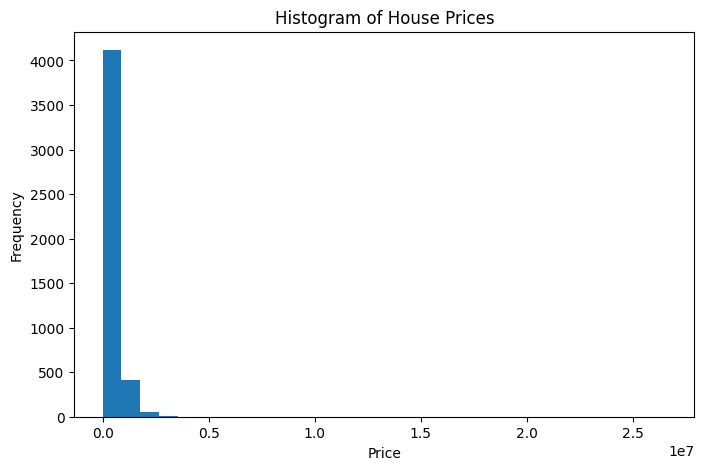

In [26]:

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of House Prices')
plt.show()


## Cumulative Frequency Distribution

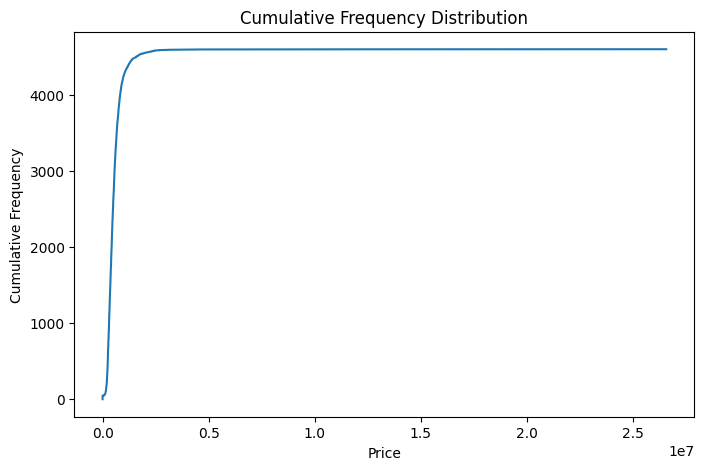

In [27]:

sorted_prices = np.sort(df['price'])
cumulative = np.arange(1, len(sorted_prices)+1)

plt.figure(figsize=(8,5))
plt.plot(sorted_prices, cumulative)
plt.xlabel('Price')
plt.ylabel('Cumulative Frequency')
plt.title('Cumulative Frequency Distribution')
plt.show()


## Measures of Central Tendency

In [28]:

numerical_cols = df.select_dtypes(include=np.number).columns

mean_values = df[numerical_cols].mean()
median_values = df[numerical_cols].median()
mode_values = df[numerical_cols].mode().iloc[0]

central_tendency = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Mode': mode_values
})

central_tendency


,Mean,Median,Mode
price,551962.988473,460943.461539,0.0
bedrooms,3.400870,3.000000,3.0
bathrooms,2.160815,2.250000,2.5
sqft_living,2139.346957,1980.000000,1720.0
sqft_lot,14852.516087,7683.000000,5000.0
floors,1.512065,1.500000,1.0
waterfront,0.007174,0.000000,0.0
view,0.240652,0.000000,0.0
condition,3.451739,3.000000,3.0
sqft_above,1827.265435,1590.000000,1010.0


## Measures of Dispersion

In [29]:

variance_values = df[numerical_cols].var()
std_values = df[numerical_cols].std()
range_values = df[numerical_cols].max() - df[numerical_cols].min()

dispersion = pd.DataFrame({
    'Variance': variance_values,
    'Standard Deviation': std_values,
    'Range': range_values
})

dispersion


,Variance,Standard Deviation,Range
price,3.179096e+11,563834.702547,26590000.0
bedrooms,8.260049e-01,0.908848,9.0
bathrooms,6.143128e-01,0.783781,8.0
sqft_living,9.277676e+05,963.206916,13170.0
sqft_lot,1.287693e+09,35884.436145,1073580.0
floors,2.897544e-01,0.538288,2.5
waterfront,7.123997e-03,0.084404,1.0
view,6.059139e-01,0.778405,4.0
condition,4.586402e-01,0.677230,4.0
sqft_above,7.433353e+05,862.168977,9040.0


## Quartiles and Interquartile Range (IQR)

In [30]:

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_table = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR
})

iqr_table


,Q1,Q3,IQR
price,322875.00,654962.50,332087.50
bedrooms,3.00,4.00,1.00
bathrooms,1.75,2.50,0.75
sqft_living,1460.00,2620.00,1160.00
sqft_lot,5000.75,11001.25,6000.50
floors,1.00,2.00,1.00
waterfront,0.00,0.00,0.00
view,0.00,0.00,0.00
condition,3.00,4.00,1.00
sqft_above,1190.00,2300.00,1110.00


## Coefficient of Variation

In [31]:

cv = (df[numerical_cols].std() / df[numerical_cols].mean()) * 100

cv_df = pd.DataFrame({
    'Coefficient of Variation (%)': cv
})

cv_df


,Coefficient of Variation (%)
price,102.150817
bedrooms,26.723992
bathrooms,36.272471
sqft_living,45.023408
sqft_lot,241.605099
floors,35.599548
waterfront,1176.537426
view,323.456341
condition,19.619958
sqft_above,47.183565


## Five Number Summary

In [32]:

five_number_summary = pd.DataFrame({
    'Minimum': df[numerical_cols].min(),
    'Q1': df[numerical_cols].quantile(0.25),
    'Median': df[numerical_cols].median(),
    'Q3': df[numerical_cols].quantile(0.75),
    'Maximum': df[numerical_cols].max()
})

five_number_summary


,Minimum,Q1,Median,Q3,Maximum
price,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,0.0,3.00,3.000000,4.00,9.0
bathrooms,0.0,1.75,2.250000,2.50,8.0
sqft_living,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,1.0,1.00,1.500000,2.00,3.5
waterfront,0.0,0.00,0.000000,0.00,1.0
view,0.0,0.00,0.000000,0.00,4.0
condition,1.0,3.00,3.000000,4.00,5.0
sqft_above,370.0,1190.00,1590.000000,2300.00,9410.0


## Boxplot

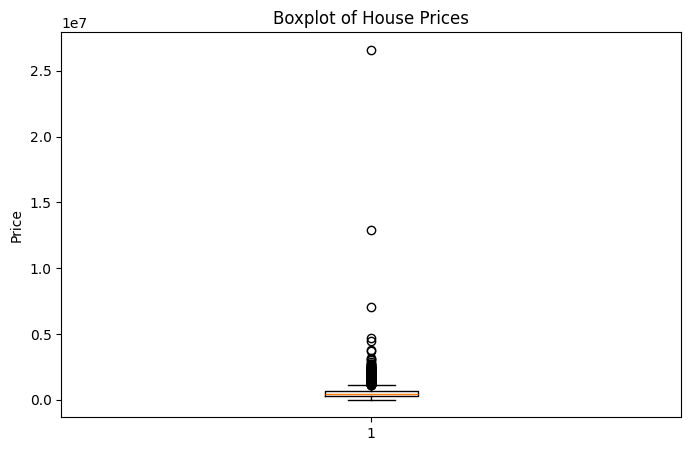

In [33]:

plt.figure(figsize=(8,5))
plt.boxplot(df['price'])
plt.title('Boxplot of House Prices')
plt.ylabel('Price')
plt.show()


## QQ Plot

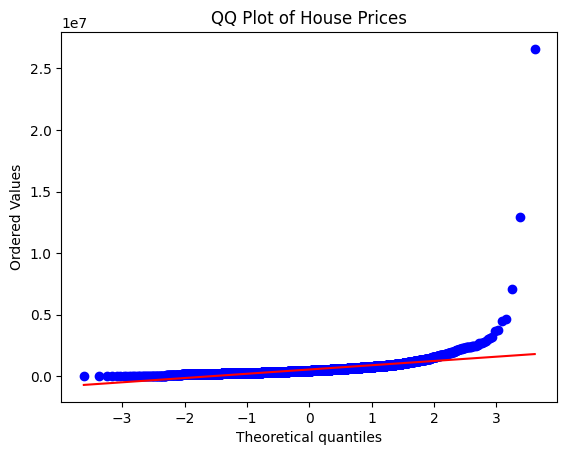

In [34]:

stats.probplot(df['price'], dist="norm", plot=plt)
plt.title('QQ Plot of House Prices')
plt.show()


## Scatter Plot

In [35]:

if 'area' in df.columns:
    plt.figure(figsize=(8,5))
    plt.scatter(df['area'], df['price'])
    plt.xlabel('Area')
    plt.ylabel('Price')
    plt.title('Area vs Price')
    plt.show()


## Z-Score Analysis

In [36]:

price_mean = df['price'].mean()
price_std = df['price'].std()

df['price_zscore'] = (df['price'] - price_mean) / price_std

df[['price', 'price_zscore']].head()


,price,price_zscore
0,313000.0,-0.423817
1,2384000.0,3.249245
2,342000.0,-0.372384
3,420000.0,-0.234046
4,550000.0,-0.003481


## Outlier Detection Using Z-Score

In [37]:

outliers = df[np.abs(df['price_zscore']) > 3]

print("Number of Outliers:", len(outliers))

outliers[['price', 'price_zscore']].head()


Number of Outliers: 34


,price,price_zscore
1,2384000.0,3.249245
122,2280000.0,3.064794
252,3200000.0,4.696478
404,2400000.0,3.277622
581,2555000.0,3.552525


## Normal Distribution Visualization

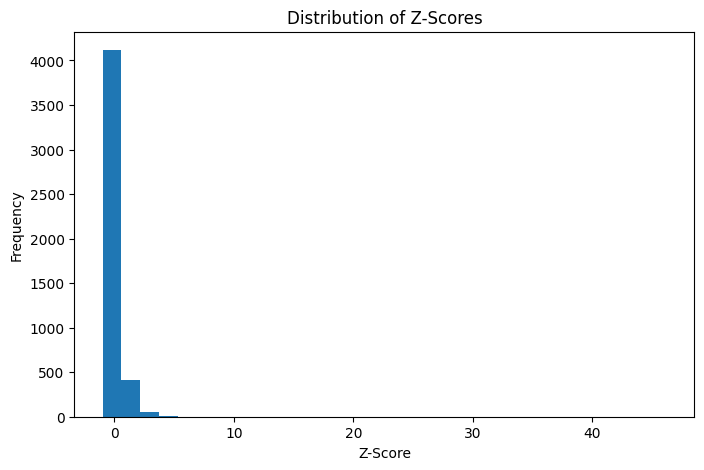

In [38]:

plt.figure(figsize=(8,5))
plt.hist(df['price_zscore'], bins=30)
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.title('Distribution of Z-Scores')
plt.show()


## Correlation Analysis

In [39]:

correlation_matrix = df[numerical_cols].corr()

correlation_matrix


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


## Correlation with Price

In [40]:

correlation_matrix['price'].sort_values(ascending=False)


price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64

## Correlation Heatmap Style Visualization

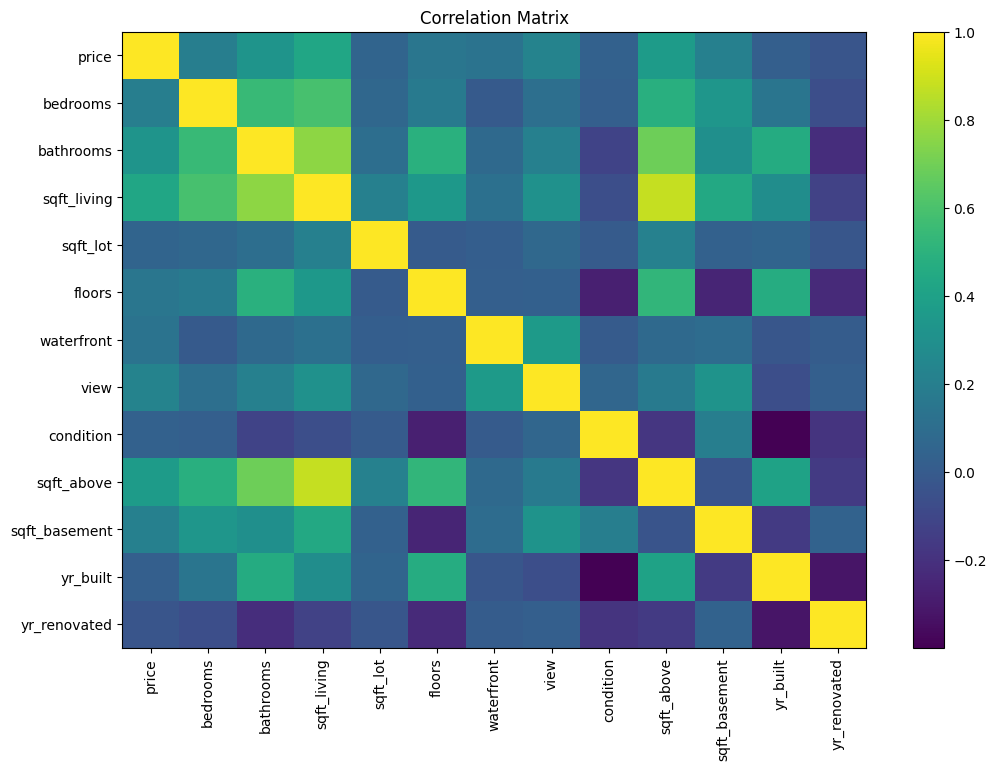

In [41]:

plt.figure(figsize=(12,8))
plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title('Correlation Matrix')
plt.show()


## T-Test Example

In [42]:

# Example split using median price
median_price = df['price'].median()

high_price = df[df['price'] >= median_price]['price']
low_price = df[df['price'] < median_price]['price']

t_stat, p_value = stats.ttest_ind(high_price, low_price)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)


T-Statistic: 31.410364709305377
P-Value: 2.269495936251321e-196



## Conclusion

This notebook applies nearly all practical statistical concepts from the uploaded lectures directly to the House Price dataset, including:

- Central Tendency
- Dispersion
- Histograms
- Cumulative Frequency
- IQR
- Coefficient of Variation
- Five Number Summary
- Boxplots
- Scatter Plots
- Scatter Matrix
- Z-Score Analysis
- Correlation
- T-Test
